# Toy ring denoiser: SC_DEQ on 2D ring data

Train the SC_DEQ model (from `recurrent_diffusion_pkg.model`) with EDM-style denoising loss on points sampled on a ring.

In [17]:
# Auto-reload local modules after edits (no kernel restart needed)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import math
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from recurrent_diffusion_pkg.model import *
from matplotlib.colors import LightSource


def edm_loss_2d(net, points, noise_range=(0.05, 0.8), P_mean=-1.2, P_std=1.2, sigma_data=0.25, edm_weighting=True):
    """EDM denoising loss for 2D data (B, D). Returns per-pixel squared error (B, D)."""
    device = points.device
    B = points.shape[0]
    rnd = torch.randn(B, 1, device=device)
    sigma = (rnd * P_std + P_mean).exp()
    if noise_range[0] is not None:
        sigma = sigma.clamp_min(noise_range[0])
    if noise_range[1] is not None:
        sigma = sigma.clamp_max(noise_range[1])
    y = points
    n = torch.randn_like(y) * sigma
    y_noisy = y + n
    D_yn = net(y_noisy, noise_labels=sigma.squeeze(1))
    se = (D_yn - y) ** 2
    if edm_weighting:
        w = (sigma ** 2 + sigma_data ** 2) / (sigma * sigma_data) ** 2
        se = w * se
    return se

## Dataset: points on a ring

In [144]:
import matplotlib.pyplot as plt
import math
import torch

def plot_samples(batch_data, grid, num_cols=4, figsize=(15, 10)):
    """
    Plots a batch of 1D signals on a grid.
    
    Args:
        batch_data: Tensor of shape (Batch, D) containing the signals.
        grid: Tensor containing the 1D domain (x-axis) values.
        num_cols: Number of columns in the visualization grid.
        figsize: Size of the entire figure.
    """
    batch_size = batch_data.shape[0]
    num_rows = math.ceil(batch_size / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten() # Flatten so we can iterate linearly
    
    for i in range(batch_size):
        # Move data to CPU and numpy for plotting
        y_data = batch_data[i].cpu().numpy()
        x_data = grid.cpu().numpy()
        
        axes[i].plot(x_data, y_data, marker='o', markersize=3, color='teal')
        axes[i].set_title(f"Sample {i}")
        axes[i].grid(True, alpha=0.3)
        
    # Hide any extra empty subplots if batch_size isn't a perfect multiple of num_cols
    for j in range(batch_size, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


def plot_samples_denoise(model, clean_batch, grid, sigma=1.5, device='cuda', num_cols=4, figsize=(16, 12)):
    """
    Adds noise to a batch, denoises it through the model, and plots 
    the clean, noisy, and denoised signals together on a grid.
    """
    model.eval()
    clean_batch = clean_batch.to(device)
    
    # 1. Generate noisy data and denoise
    with torch.no_grad():
        noisy = clean_batch + sigma * torch.randn_like(clean_batch)
        noise_labels = torch.full((noisy.shape[0],), sigma, device=device, dtype=noisy.dtype)
        denoised = model(noisy, noise_labels=noise_labels)
        
    # 2. Set up the plotting grid
    batch_size = clean_batch.shape[0]
    num_rows = math.ceil(batch_size / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    
    x_data = grid.cpu().numpy()
    
    # 3. Plot each sample in the batch
    for i in range(batch_size):
        c_data = clean_batch[i].cpu().numpy()
        n_data = noisy[i].cpu().numpy()
        d_data = denoised[i].cpu().numpy()
        
        # Plot Noisy (scattered, light red so it doesn't overpower)
        axes[i].plot(x_data, n_data, label='Noisy', color='red', alpha=0.3, markersize=4)
        # Plot Clean (solid green)
        axes[i].plot(x_data, c_data, label='Clean', color='green', linewidth=2)
        # Plot Denoised (dashed blue)
        axes[i].plot(x_data, d_data, label='Denoised', color='blue', linestyle='--', linewidth=2)
        
        axes[i].set_title(f"Sample {i}")
        axes[i].grid(True, alpha=0.3)
        
        # Only add the legend to the first subplot to save visual space
        if i == 0:
            axes[i].legend()
            
    # Hide any extra empty subplots
    for j in range(batch_size, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import torch
import math

def plot_sample_ring(dataset, idx=0, base_radius=1.0):
    """
    Visualizes a single bump protruding from a 2D ring.
    """
    signal, mu = dataset[idx]
    grid = dataset.grid
    
    # 1. Close the loop by appending the first point to the end
    grid_closed = torch.cat([grid, grid[0:1]])
    signal_closed = torch.cat([signal, signal[0:1]])
    
    # 2. Convert to polar coordinates (radius = base + amplitude)
    r = base_radius + signal_closed
    x = r * torch.cos(grid_closed)
    y = r * torch.sin(grid_closed)
    
    # 3. Create the base ring coordinates for visual reference
    x_base = base_radius * torch.cos(grid_closed)
    y_base = base_radius * torch.sin(grid_closed)
    
    # Plotting
    plt.figure(figsize=(6, 6))
    
    # Plot the base ring
    # plt.plot(x_base.numpy(), y_base.numpy(), linestyle='--', color='gray', alpha=0.5, label='Domain Ring')
    
    # Plot the signal protruding from the ring
    plt.plot(x.numpy(), y.numpy(), color='teal', linewidth=2)
    plt.fill(x.numpy(), y.numpy(), color='teal', alpha=0.2) # Fills the shape for better visibility
    
    # Mark the center of the bump (mu)
    mu_x = (base_radius + 1.2) * math.cos(mu.item()) # slightly further out
    mu_y = (base_radius + 1.2) * math.sin(mu.item())
    plt.plot([0, mu_x], [0, mu_y], color='red', label=f'Center (μ={mu.item():.2f})')
    
    plt.title(f"Bump on a Ring (Sample {idx})")
    plt.axis('equal') # Ensures the ring isn't squished into an oval
    plt.axis('off')   # Hides the standard square grid
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_batch_rings(batch_data, grid, num_cols=4, figsize=(15, 10), base_radius=1.0,name="sample", title = True):
    """
    Plots a batch of signals as rings on a grid with consistent scaling.
    """
    batch_size = batch_data.shape[0]
    num_rows = math.ceil(batch_size / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    
    # Close the grid loop once for the whole batch
    grid_closed = torch.cat([grid, grid[0:1]])
    x_base = base_radius * torch.cos(grid_closed).cpu().numpy()
    y_base = base_radius * torch.sin(grid_closed).cpu().numpy()
    
    # Calculate the absolute maximum extent so all plots share the exact same scale
    max_extent = base_radius + torch.max(batch_data).item() + 0.2
    
    for i in range(batch_size):
        # Close the signal loop
        signal = batch_data[i]
        signal_closed = torch.cat([signal, signal[0:1]])
        
        # Calculate coordinates
        r = base_radius + signal_closed.cpu()
        x = r * torch.cos(grid_closed.cpu()).numpy()
        y = r * torch.sin(grid_closed.cpu()).numpy()
        
        # Plot base ring (solid light gray for clear reference)
        # axes[i].plot(x_base, y_base, linestyle='-', color='gray', alpha=0.3)
        
        # Plot the bump as a dotted red line
        axes[i].plot(x, y, color='red', linewidth=2)
        if title:
            axes[i].set_title(name + f"{i}")
        
        # Lock the axis limits so the base rings never change size
        axes[i].set_xlim(-max_extent, max_extent)
        axes[i].set_ylim(-max_extent, max_extent)
        
        # Use set_aspect instead of axis('equal') to respect our strict limits
        axes[i].set_aspect('equal')
        axes[i].axis('off')
        
    for j in range(batch_size, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    # plt.show()
    
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/{}.png'.format(name), dpi=100)
    
    # # # 4. CRITICAL: Close the plot so Jupyter doesn't try to send it to your browser
    plt.close()


import matplotlib.pyplot as plt
import torch
import math

def plot_samples_denoise_ring(model, clean_batch, grid, noisy =None, sigma=1.5, device='cuda', num_cols=8, figsize=(16, 4), base_radius=1.5):
    """
    Adds noise to a batch, denoises it through the model, and plots 
    the clean, noisy, and denoised signals as overlapping rings.
    """
    model.eval()
    clean_batch = clean_batch.to(device)
    
    # 1. Generate noisy data and denoise
    with torch.no_grad():
        if noisy is None:
            noisy = clean_batch + sigma * torch.randn_like(clean_batch)
        noise_labels = torch.full((noisy.shape[0],), sigma, device=device, dtype=noisy.dtype)
        denoised = model(noisy, noise_labels=noise_labels)
        
    # 2. Set up the plotting grid
    batch_size = clean_batch.shape[0]
    num_rows = math.ceil(batch_size / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    
    # 3. Prepare the closed-loop base grid once
    grid_closed = torch.cat([grid, grid[0:1]]).cpu()
    cos_grid = torch.cos(grid_closed)
    sin_grid = torch.sin(grid_closed)
    
    x_base = base_radius * cos_grid.numpy()
    y_base = base_radius * sin_grid.numpy()
    
    # Determine absolute bounds using the noisy data, as it has the widest spikes
    max_extent = base_radius + torch.max(clean_batch).item() + 0.5
    
    # Move everything to CPU for Matplotlib
    clean_batch = clean_batch.cpu()
    noisy = noisy.cpu()
    denoised = denoised.cpu()
    
    # 4. Plot each sample in the batch
    for i in range(batch_size):
        # Close loops for all signals
        c_data = torch.cat([clean_batch[i], clean_batch[i][0:1]])
        n_data = torch.cat([noisy[i], noisy[i][0:1]])
        d_data = torch.cat([denoised[i], denoised[i][0:1]])
        
        # Convert to polar coordinates
        x_clean = (base_radius + c_data) * cos_grid
        y_clean = (base_radius + c_data) * sin_grid
        
        x_noisy = (base_radius + n_data) * cos_grid
        y_noisy = (base_radius + n_data) * sin_grid
        
        x_denoised = (base_radius + d_data) * cos_grid
        y_denoised = (base_radius + d_data) * sin_grid
        
        # Plot Base Ring (solid light gray)
        # axes[i].plot(x_base, y_base, linestyle='-', color='gray', alpha=0.3)
        
        # Plot Noisy (scattered, light red crosses)
        axes[i].plot(x_noisy.numpy(), y_noisy.numpy(), label='Noisy', color='red', alpha=0.3, markersize=4)
        
        # Plot Clean (solid green)
        axes[i].plot(x_clean.numpy(), y_clean.numpy(), label='Clean', color='green', linewidth=2)
        
        # Plot Denoised (dashed blue)
        axes[i].plot(x_denoised.numpy(), y_denoised.numpy(), label='Denoised', color='blue', linestyle='--', linewidth=2)
        
        axes[i].set_title(f"Sample {i}")
        
        # Lock axes to prevent shrinking/growing
        axes[i].set_xlim(-max_extent, max_extent)
        axes[i].set_ylim(-max_extent, max_extent)
        axes[i].set_aspect('equal')
        axes[i].axis('off')
        
        # Add legend to the first subplot only
        if i == 0:
            axes[i].legend(loc='upper right', fontsize='small')
            
    # Hide extra empty subplots
    for j in range(batch_size, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

import os
import torch
def load_model(exp_name):
    # 1. Define where to find the checkpoint
    save_dir = "checkpoints"
    load_path = os.path.join(save_dir, exp_name, "latest_checkpoint.pt")
    
    # 2. Load the raw checkpoint dictionary into CPU memory first (safest approach)
    print(f"Loading checkpoint from {load_path}...")
    checkpoint = torch.load(load_path, map_location='cpu', weights_only=False)
    
    # 3. Extract the saved hyperparameters
    hparams = checkpoint.get('hparams', {})
    print(f"Loaded Hyperparameters: {hparams}")
    
    # 4. Instantiate a fresh model dynamically using those exact hparams
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = SC_DEQ(
        data_dim=hparams["data_dim"],
        hidden_dim=hparams["hidden_dim"],
        eta=hparams["eta"],
        lam=hparams["lam"],
        jfb_no_grad_iters=hparams["jfb_no_grad_iters"],
        jfb_with_grad_iters=hparams["jfb_with_grad_iters"],
        learning_horizontal=hparams["learning_horizontal"]
    ).to(device)
    
    # 5. Pour the saved weights into the blank model
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # 6. (Optional) Rebuild the optimizer if you plan to resume training
    optimizer = torch.optim.Adam(model.parameters(), lr=hparams["lr"])
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # 7. Set the model to evaluation mode (Important if you are just doing inference!)
    model.eval()
    
    print(f"Successfully restored model from Epoch {checkpoint['epoch']} (Loss: {checkpoint['loss']:.6f})")
    return model, optimizer


In [145]:
import torch
import math
from torch.utils.data import Dataset

class AsymmetricCrossDataset(Dataset):
    def __init__(self, num_samples=5000, d_dim=128, chunk_length=0):
        """
        Generates 1D 'Asymmetric Cross' signals.
        Strictly follows the sparse coding generative assumption: x = Phi * a.
        The manifold is defined by 2 coordinates: [Rotation (mu), Width (sigma)].
        """
        self.num_samples = num_samples
        self.d_dim = d_dim
        self.chunk_length = chunk_length

        self.grid = torch.linspace(0, 2 * math.pi, d_dim + 1)[:-1]

        # ---------------------------------------------------------
        # GENERATIVE ATTRIBUTES 
        # ---------------------------------------------------------
        # The surround is now an intrinsic property of the dictionary element Phi
        self.inhibitory_surround = 0.25
        
        # Jitter parameters
        self.std_mu = 0.1        # Rotational jitter
        self.std_sigma = 0.05    # Tightly controlled width jitter

        # ---------------------------------------------------------
        # STOCHASTIC MANIFOLD SAMPLING (S1 x W)
        # ---------------------------------------------------------
        mu_base = torch.rand(num_samples, 1) * 2 * math.pi
        
        # Restored the beautiful sigma ranges [0.2, 0.4] around the ideal 0.3 mark
        sigma_base_major = 0.1 + 0.3 * torch.rand(num_samples, 1)
        sigma_base_minor = 0.1 + 0.3 * torch.rand(num_samples, 1)

        # 2. Generate the 4 individual blades 
        # MAJOR AXIS -> Amplitude is the sparse code 'a' = 1.2
        mu_N = (mu_base + torch.randn(num_samples, 1) * self.std_mu) % (2 * math.pi)
        sigma_N = torch.clamp(sigma_base_major + torch.randn(num_samples, 1) * self.std_sigma, min=0.15, max=0.45)
        scale_N = torch.full((num_samples, 1), 1.2)

        mu_S = (mu_base + math.pi + torch.randn(num_samples, 1) * self.std_mu) % (2 * math.pi)
        sigma_S = torch.clamp(sigma_base_major + torch.randn(num_samples, 1) * self.std_sigma, min=0.15, max=0.45)
        scale_S = torch.full((num_samples, 1), 1.2)

        # MINOR AXIS -> Amplitude is the sparse code 'a' = 0.7
        mu_E = (mu_base + math.pi/2 + torch.randn(num_samples, 1) * self.std_mu) % (2 * math.pi)
        sigma_E = torch.clamp(sigma_base_minor + torch.randn(num_samples, 1) * self.std_sigma, min=0.15, max=0.45)
        scale_E = torch.full((num_samples, 1), 0.7)

        mu_W = (mu_base - math.pi/2 + torch.randn(num_samples, 1) * self.std_mu) % (2 * math.pi)
        sigma_W = torch.clamp(sigma_base_minor + torch.randn(num_samples, 1) * self.std_sigma, min=0.15, max=0.45)
        scale_W = torch.full((num_samples, 1), 0.7)

        # 3. Store the [num_samples, 4, 2] tensor: strictly (mu, sigma)
        coords_N = torch.cat([mu_N, sigma_N, scale_N], dim=1)
        coords_S = torch.cat([mu_S, sigma_S, scale_S], dim=1)
        coords_E = torch.cat([mu_E, sigma_E, scale_E], dim=1)
        coords_W = torch.cat([mu_W, sigma_W, scale_W], dim=1)
        
        self.manifold_coords = torch.stack([coords_N, coords_S, coords_E, coords_W], dim=1)

        # 4. Generate the full dataset using (mu, sigma, amplitude) tuples
        components = [
            (mu_N, sigma_N, scale_N),
            (mu_S, sigma_S, scale_S),
            (mu_E, sigma_E, scale_E),
            (mu_W, sigma_W, scale_W)
        ]
        self.data = self.generate(components)


    def generate(self, components):
        batch_size = components[0][0].shape[0]
        signal = torch.zeros(batch_size, self.d_dim, device=self.grid.device)

        for mu, sigma, amplitude in components:
            mu = mu.view(batch_size, 1)
            sigma = sigma.view(batch_size, 1)
            amplitude = amplitude.view(batch_size, 1)
            
            loc = ((self.grid - mu + math.pi) % (2 * math.pi)) - math.pi
            
            # 1. Define the fundamental dictionary element (Phi_i)
            # The inhibitory surround is an intrinsic part of the unscaled shape
            base_blade = torch.exp(-torch.abs(loc) / sigma) 
            # - self.inhibitory_surround
            
            # 2. Strict Linear Combination: x = a * Phi_i
            # blade = amplitude * base_blade
            
            signal += base_blade

        return signal


    def get_grid_samples(self, mu_steps=72, sigma_steps=10):
        mu_vals = torch.linspace(0, 2 * math.pi, mu_steps + 1)[:-1]
        sigma_vals = torch.linspace(0.15, 0.45, sigma_steps)
        
        mu_grid, sigma_grid = torch.meshgrid(mu_vals, sigma_vals, indexing='ij')
        mu_flat = mu_grid.flatten().unsqueeze(1)
        sigma_flat = sigma_grid.flatten().unsqueeze(1)
        
        grid_coords = torch.cat([mu_flat, sigma_flat], dim=1)
        
        # To extract the raw dictionary matrix Phi, we set amplitude 'a' = 1.0
        amplitude_flat = torch.ones_like(mu_flat)
        
        components = [
            (mu_flat, sigma_flat, amplitude_flat)
        ]
        
        # This now returns EXACTLY the dictionary elements, properly scaled.
        grid_data = self.generate(components)
        return grid_data, grid_coords

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        if self.chunk_length == 0:
            return self.data[idx], self.manifold_coords[idx]
        indices = [(idx + i) % self.num_samples for i in range(self.chunk_length)]
        return self.data[indices], self.manifold_coords[indices]

## 1. Data Distribution figures

In [146]:
dataset = AsymmetricCrossDataset(num_samples=10000, d_dim =128)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)
grid = dataset.grid
sample_batch, sample_m_coordinate = next(iter(dataloader))
print(f"Data batch shape: {sample_batch.shape}")       # [128, 2]
print(f"Indices batch shape: {sample_m_coordinate.shape}")  # [128]

plot_batch_rings(sample_batch[:16]-1, grid, num_cols=4, figsize=(5,6), base_radius=1.5, title =False)

Data batch shape: torch.Size([16, 128])
Indices batch shape: torch.Size([16, 4, 3])


/tmp/ipykernel_548418/3665269652.py:159: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = r * torch.cos(grid_closed.cpu()).numpy()
/tmp/ipykernel_548418/3665269652.py:160: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y = r * torch.sin(grid_closed.cpu()).numpy()


## 2. Manifold hypothesis (Visualize generation process)

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LightSource

def plot_stochastic_sample(generated_signal, manifold_coords):
    """
    Plots a side-by-side comparison for a stochastic dataset sample:
    Left: The slightly elliptical 3D Manifold with the 4 jittered causal sparse codes.
          - Y-axis position represents blade Width (sigma).
          - Spike length represents sparse code Amplitude (a).
    Right: The resulting generated Asymmetric Cross Star.
    """
    # 1. Convert PyTorch tensors to NumPy arrays
    if isinstance(manifold_coords, torch.Tensor):
        coords = manifold_coords.detach().cpu().numpy()
    if isinstance(generated_signal, torch.Tensor):
        signal = generated_signal.detach().cpu().numpy()

    # Set up the 1x2 side-by-side figure
    fig = plt.figure(figsize=(16, 7))
    gs = GridSpec(1, 2, width_ratios=[5, 1])
    
    # ==========================================
    # LEFT PANEL: Latent Manifold & Sparse Code
    # ==========================================
    ax1 = fig.add_subplot(gs[0, 0], projection='3d')
    
    width_scale = 0.2   
    ellipse_squish = 0.6 
    
    def get_normal(mu_angle):
        nx = np.cos(mu_angle)
        nz = np.sin(mu_angle) / ellipse_squish
        norm = np.sqrt(nx**2 + nz**2)
        return nx / norm, nz / norm

    # Draw the Continuous Belt Surface
    z_surf_base = np.linspace(0, 1, 50)
    theta_surf = np.linspace(0, 2 * np.pi, 80)
    theta_grid, s_grid = np.meshgrid(theta_surf, z_surf_base)
    
    x_surf = np.cos(theta_grid)
    y_surf = width_scale * (s_grid - 0.5)
    z_surf = ellipse_squish * np.sin(theta_grid)
    
    ls = LightSource(azdeg=225, altdeg=20) 
    rgb = ls.shade(z_surf, 
                   cmap=plt.colormaps['Greys'], 
                   blend_mode='overlay', 
                   fraction=0.4) 
    
    ax1.plot_surface(x_surf, y_surf, z_surf, 
                     rstride=1, cstride=1,
                     facecolors=rgb, 
                     linewidth=0, 
                     antialiased=True, 
                     shade=False, 
                     alpha=0.4)

    for s_val in [0, 1]:
        y_edge = width_scale * (s_val - 0.5)
        ax1.plot(np.cos(theta_surf), [y_edge]*len(theta_surf), ellipse_squish * np.sin(theta_surf), 
                 color='black', alpha=0.15, lw=0.7)

    # --- KEY UPDATE: Extract all 3 coordinates (mu, sigma, amplitude) ---
    mu_q = coords[:, 0]
    sigma_q = coords[:, 1]
    amplitude_q = coords[:, 2] # <--- Extract amplitude directly from the dataset coords
    
    # Normalize sigma to [0, 1] so it spans the width of the belt
    # Using bounds [0.1, 0.5] as safe visualization bounds based on dataset generation
    min_s, max_s = 0.1, 0.5
    size_q = (sigma_q - min_s) / (max_s - min_s + 1e-8)

    plotted_gt_legend = False
    for i in range(coords.shape[0]):
        # Position on the belt dictates both Rotation (X, Z) and Width (Y)
        X_q = np.cos(mu_q[i])
        Y_q = width_scale * (size_q[i] - 0.5)  
        Z_q = ellipse_squish * np.sin(mu_q[i])
        
        nq_x, nq_z = get_normal(mu_q[i])
        
        # Scale the spike length dynamically based on the dataset's amplitude coordinate
        spike_len = 0.6 * (amplitude_q[i] / 1.2) 

        ax1.plot([X_q, X_q + nq_x * spike_len], 
                 [Y_q, Y_q], 
                 [Z_q, Z_q + nq_z * spike_len], 
                 color='red', linewidth=3, 
                 label='True h sparse signal (h=4)' if not plotted_gt_legend else "")
        
        ax1.scatter([X_q + nq_x * spike_len], [Y_q], [Z_q + nq_z * spike_len], 
                    color='red', s=100, marker='*', zorder=6)
        
        plotted_gt_legend = True

    ax1.set_axis_off()
    ax1.set_box_aspect([2, width_scale * 2, ellipse_squish * 2]) 
    ax1.legend(loc='lower right', frameon=False, fontsize=12)

    # ==========================================
    # RIGHT PANEL: Generated Pixel Space Object
    # ==========================================
    ax2 = fig.add_subplot(gs[0, 1])
    
    d_dim = len(signal)
    grid = np.linspace(0, 2 * np.pi, d_dim + 1)[:-1]

    base_radius = 1.5
    r = base_radius + signal
    
    r_closed = np.append(r, r[0])
    theta_closed = np.append(grid, grid[0])
    
    x_star = r_closed * np.cos(theta_closed)
    y_star = r_closed * np.sin(theta_closed)

    ax2.plot(x_star, y_star, color='red', linewidth=4)
    ax2.set_aspect('equal')
    ax2.axis('off')

    plt.tight_layout()
    # plt.show()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/causal.png', dpi=100)
    
    # 4. CRITICAL: Close the plot so Jupyter doesn't try to send it to your browser
    plt.close()


signal, coords = dataset[0]
plot_stochastic_sample(sample_batch[0]-1, sample_m_coordinate[0])

## 3. Sparse coding (Functional approximation view)

In [37]:
class TiedTranspose(nn.Module):
    def __init__(self, linear: nn.Linear):
        super().__init__()
        self.linear = linear

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert self.linear.bias is None
        return F.linear(x, self.linear.weight.t(), None)

    @property
    def weight(self) -> torch.Tensor:
        return self.linear.weight.t()

    @property
    def bias(self) -> torch.Tensor:
        return self.linear.bias


class SC_inference(nn.Module):
    """Single-step sparse coding inference: a = relu(a_prev + eta * (constraint_ff + noise_emb * (prior_term + lam)))."""

    def __init__(self, data_dim: int, hidden_dim: int, eta: float = 0.1, lam: float = 0.0, learning_horizontal=True):
        super().__init__()
        self.eta = eta
        # self.lam = nn.Parameter(torch.full((1,), float(lam)))
        self.lam = lam
        self.Phi = nn.Linear(hidden_dim, data_dim, bias=False)
        # self.Phi_T = nn.Linear(data_dim, hidden_dim, bias=False)
        self.Phi_T = TiedTranspose(self.Phi)
        if learning_horizontal:
            self.M = nn.Linear(hidden_dim, hidden_dim, bias=False)
        else:
            self.M = None

    def forward(self, x: torch.Tensor, a_prev: torch.Tensor, noise_emb: torch.Tensor) -> torch.Tensor:
        # x: [B, data_dim], a_prev: [B, hidden_dim] or None, noise_emb: [B, hidden_dim]
        # Phi_T encodes x -> latent: [B, data_dim] -> [B, hidden_dim]; Phi decodes a -> x
        prior_term = self.M(a_prev) if (a_prev is not None and self.M is not None) else 0.0
        constraint_ff = self.Phi_T(x - self.Phi(a_prev)) if a_prev is not None else self.Phi_T(x)

        if a_prev is None:
            a = self.eta * (constraint_ff + noise_emb * self.lam)
        else:
            a = a_prev + self.eta * (constraint_ff + noise_emb * (self.lam + prior_term))
        return F.relu(a)


In [32]:
grid_dictionary, grid_coords = dataset.get_grid_samples(mu_steps=40, sigma_steps=5)

In [33]:
# plot_batch_rings(grid_dictionary[::8], grid, num_cols=10, figsize=(10,3), base_radius=1.5, title =False)

In [98]:
device = 'cpu'
sc_net = SC_inference(data_dim=128,hidden_dim=grid_dictionary.shape[0],eta=0.01,lam=-0.1,learning_horizontal=False)
# norms = torch.norm(grid_dictionary, p=2, dim=1, keepdim=True)
# normalized_samples = grid_dictionary / norms
sc_net.Phi.weight.data = grid_dictionary.T.clone().to(device)*0.5

In [99]:
# sample_batch, manifold_indices = next(iter(dataloader))

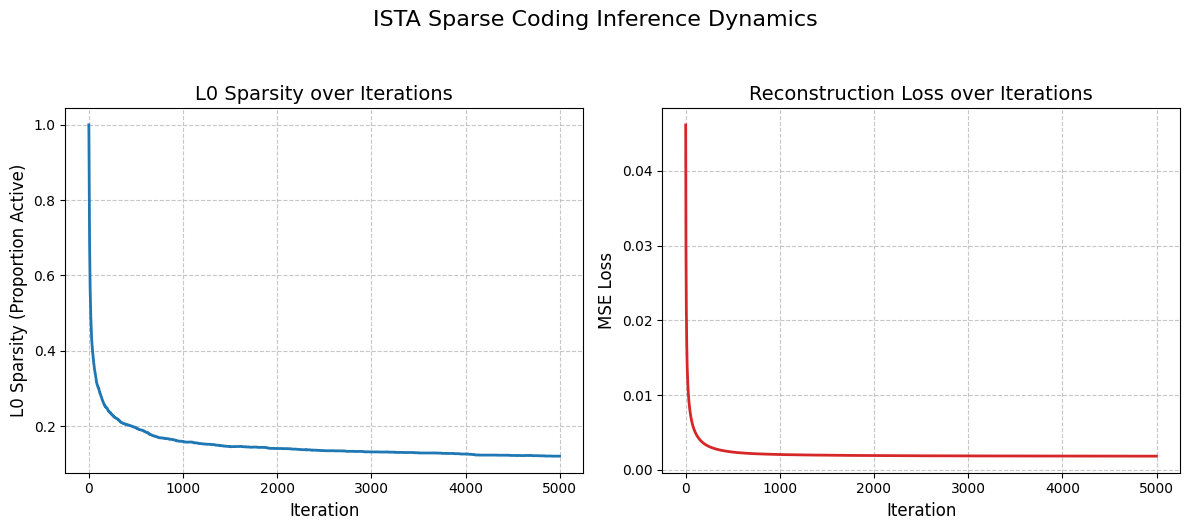

In [100]:
L0_hist = []
recon_loss_hist = []
a = None
for i in range(5000):
    with torch.no_grad():
        a = sc_net(sample_batch,a,1)
        L0 = (a>0).float().mean()
        recon = sc_net.Phi(a)
        recon_loss = ((sample_batch - recon)**2).mean()
        L0_hist.append(L0.cpu())
        recon_loss_hist.append(recon_loss.cpu())

import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- First Subplot: L0 Sparsity ---
axes[0].plot(L0_hist, color='#1f77b4', linewidth=2)
axes[0].set_title('L0 Sparsity over Iterations', fontsize=14)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('L0 Sparsity (Proportion Active)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- Second Subplot: Reconstruction Loss ---
# We use range(1, len) so the x-axis matches the actual iteration step
iterations_loss = range(1, len(recon_loss_hist))
axes[1].plot(iterations_loss, recon_loss_hist[1:], color='#d62728', linewidth=2)
axes[1].set_title('Reconstruction Loss over Iterations', fontsize=14)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- Overall Figure Formatting ---
fig.suptitle('ISTA Sparse Coding Inference Dynamics', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
import torch
from matplotlib.colors import LightSource

def visualize_sparse_coding_full_evaluation(grid_coords, query_label, sparse_code, 
                                            sample_signal, reconstruction_signal, name = "approximation",ground_truth=True):
    """
    Plots a side-by-side evaluation of the sparse coding network.
    Left: 3D Manifold Belt with GT (red) and Inferred (blue) sparse codes.
    Right: 2D Polar Space showing the actual Sample (red) vs Reconstruction (blue).
    """
    # ==========================================
    # 0. Data Preparation (Tensors -> NumPy)
    # ==========================================
    def to_np(t):
        if isinstance(t, torch.Tensor):
            return t.detach().cpu().numpy()
        return np.array(t)

    mu_g = to_np(grid_coords)[:, 0]
    scale_g = to_np(grid_coords)[:, 1]
    a_vals = to_np(sparse_code)
    
    query_label = to_np(query_label) 
    mu_q = query_label[:, 0]
    scale_q = query_label[:, 1]
    
    sample = to_np(sample_signal)-1
    recon = to_np(reconstruction_signal)-1

    # --- Normalize scales to [0, 1] so they perfectly hug the belt ---
    min_s, max_s = np.min(scale_g), np.max(scale_g)
    size_g = (scale_g - min_s) / (max_s - min_s + 1e-8)
    size_q = (scale_q - min_s) / (max_s - min_s + 1e-8)
    
    # --- SYNCHRONIZED GEOMETRY PARAMETERS ---
    width_scale = 0.2   
    ellipse_squish = 0.6 
    
    # Setup Figure and GridSpec
    fig = plt.figure(figsize=(16, 7))
    gs = GridSpec(1, 2, width_ratios=[7, 1])
    

    # ==========================================
    # LEFT PANEL: 3D Latent Manifold & Sparse Codes
    # ==========================================
    ax1 = fig.add_subplot(gs[0, 0], projection='3d')
    
    X_g = np.cos(mu_g)
    Y_g = width_scale * (size_g - 0.5) 
    Z_g = ellipse_squish * np.sin(mu_g)
    
    def get_normal(mu_angle):
        nx = np.cos(mu_angle)
        nz = np.sin(mu_angle) / ellipse_squish
        norm = np.sqrt(nx**2 + nz**2)
        return nx / norm, nz / norm

    # --- 1. The Belt Manifold (Ellipsoid Surface) ---
    z_surf_base = np.linspace(0, 1, 50)
    theta_surf = np.linspace(0, 2*np.pi, 80)
    theta_grid, s_grid = np.meshgrid(theta_surf, z_surf_base)
    
    x_surf = np.cos(theta_grid)
    y_surf = width_scale * (s_grid - 0.5)
    z_surf = ellipse_squish * np.sin(theta_grid)
    ls = LightSource(azdeg=225, altdeg=20) 
    
    # 2. Key Change: 'fraction' controls the intensity of the light. 
    # Lowering it to 0.3-0.5 keeps the "grey" look without white blowouts.
    rgb = ls.shade(z_surf, 
                   cmap=plt.colormaps['Greys'], 
                   blend_mode='overlay', 
                   fraction=0.4) # Adjust this lower if it's still too bright
    
    ax1.plot_surface(x_surf, y_surf, z_surf, 
                     rstride=1, cstride=1,
                     facecolors=rgb, 
                     linewidth=0, 
                     antialiased=True, 
                     shade=False, 
                     alpha=0.4) # Increased alpha slightly to make it more "solid" grey

    for s_val in [0, 1]:
        y_edge = width_scale * (s_val - 0.5)
        ax1.plot(np.cos(theta_surf), [y_edge]*len(theta_surf), ellipse_squish * np.sin(theta_surf), 
                 color='black', alpha=0.15, lw=0.7)
    
    # --- 2. The Dictionary Landmarks ---
    ax1.scatter(X_g, Y_g, Z_g, color='black', s=15, alpha=0.5, label='Dictionary Landmarks')

    if ground_truth:
        # --- 3. The Query Ground Truth Spikes (Red) ---
        plotted_gt_legend = False
        for j in range(query_label.shape[0]):
            q_amplitude = scale_q[j] *2
            
            X_q = np.cos(mu_q[j])
            Y_q = width_scale * (size_q[j] - 0.5)
            Z_q = ellipse_squish * np.sin(mu_q[j])
            nq_x, nq_z = get_normal(mu_q[j])
            
            gt_spike_len = 0.6 * (q_amplitude / 1.2)
            
            ax1.plot([X_q, X_q + nq_x * gt_spike_len], 
                     [Y_q, Y_q], 
                     [Z_q, Z_q + nq_z * gt_spike_len], 
                     color='red', linewidth=3, 
                     label='True h sparse signal (h=4)' if not plotted_gt_legend else "")
            ax1.scatter([X_q + nq_x * gt_spike_len], [Y_q], [Z_q + nq_z * gt_spike_len], 
                        color='red', s=100, marker='*', zorder=6)
            plotted_gt_legend = True
    
    # --- 4. The Inferred Sparse Code Spikes (Blue) ---
    max_a = np.max(np.abs(a_vals)) if np.max(np.abs(a_vals)) > 0 else 1e-5
    spike_scale = 0.6 / max_a 

    threshold = 1e-3
    plotted_sc_legend = False
    for i, val in enumerate(a_vals):
        if abs(val) > threshold:
            n_x, n_z = get_normal(mu_g[i])
            x_start, y_start, z_start = X_g[i], Y_g[i], Z_g[i]
            x_end = x_start + n_x * (val * spike_scale)
            y_end = y_start 
            z_end = z_start + n_z * (val * spike_scale)
            
            ax1.plot([x_start, x_end], [y_start, y_end], [z_start, z_end], 
                     color='blue', linewidth=2, 
                     label='Inferred Sparse Code' if not plotted_sc_legend else "")
            ax1.scatter([x_end], [y_end], [z_end], color='blue', s=20, zorder=5)
            plotted_sc_legend = True

    ax1.set_axis_off()
    ax1.set_box_aspect([2, width_scale * 2, ellipse_squish * 2]) 
    ax1.legend(loc='lower left', frameon=False, fontsize=11)

    # ==========================================
    # RIGHT PANEL: 2D Generated Pixel Space Object
    # ==========================================
    ax2 = fig.add_subplot(gs[0, 1])
    
    d_dim = len(sample)
    grid = np.linspace(0, 2 * np.pi, d_dim + 1)[:-1]
    base_radius = 1.5
    
    # --- Sample Star (Red) ---
    r_samp = base_radius + sample
    r_samp_closed = np.append(r_samp, r_samp[0])
    theta_closed = np.append(grid, grid[0])
    
    x_samp = r_samp_closed * np.cos(theta_closed)
    y_samp = r_samp_closed * np.sin(theta_closed)
    
    if ground_truth:
        ax2.plot(x_samp, y_samp, color='red', linewidth=4, alpha=0.8, label='True Signal')
    
    # --- Reconstruction Star (Blue) ---
    r_recon = base_radius + recon
    r_recon_closed = np.append(r_recon, r_recon[0])
    
    x_recon = r_recon_closed * np.cos(theta_closed)
    y_recon = r_recon_closed * np.sin(theta_closed)
    
    # Using dashed so the red stroke underneath remains visible when perfectly aligned
    ax2.plot(x_recon, y_recon, color='blue', linewidth=3, label='Approximation')

    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.legend(loc='lower left', bbox_to_anchor=(0, -0.5), frameon=False, fontsize=12)

    plt.tight_layout()
    # plt.show()
    os.makedirs('figures', exist_ok=True)
    plt.savefig('figures/{}.png'.format(name), dpi=100)
    
    # # # # 4. CRITICAL: Close the plot so Jupyter doesn't try to send it to your browser
    plt.close()


In [158]:

# ==========================================
# USAGE IN YOUR TRAINING LOOP:
# ==========================================
sample_batch, manifold_indices = next(iter(dataloader))
a = None
for i in range(5000):
    with torch.no_grad():
        a = sc_net(sample_batch, a, 1)
        recon = sc_net.Phi(a)

viz_idx = 0
visualize_sparse_coding_full_evaluation(grid_coords, manifold_indices[viz_idx], a[viz_idx], sample_batch[viz_idx], recon[viz_idx])

## 4. Factorial prior vs non-factorial prior

In [140]:
import torch
import math

# 1. Define how many independent samples you want in this batch
batch_size = 4  
h_blades = 4

independent_components = []
coord_list = [] # <--- NEW: We must track the coordinates into a proper tensor!

for _ in range(h_blades):
    # Random position [0, 2pi]
    mu_rnd = torch.rand(batch_size, 1) * (2 * math.pi)
    
    # Random width [0.15, 0.45]
    sigma_rnd = 0.15 + 0.3 * torch.rand(batch_size, 1)
    
    # Fixed uniform amplitude 
    amp_rnd = torch.ones(batch_size, 1)
    
    # Pack for the signal generator
    independent_components.append((mu_rnd, sigma_rnd, amp_rnd))
    
    # Pack for the visualizer: concatenate into shape [B, 3]
    coord_list.append(torch.cat([mu_rnd, sigma_rnd, amp_rnd], dim=1))

# 2. Generate the 1D signal using your existing class method
ind_batch = dataset.generate(independent_components)

# 3. NEW: Stack the coordinate list into a clean [B, 4, 3] tensor
ind_coords = torch.stack(coord_list, dim=1)

# ==========================================
# RUN INFERENCE
# ==========================================
a = None
for i in range(5000):
    with torch.no_grad():
        a = sc_net(ind_batch, a, 1)
        recon = sc_net.Phi(a)

In [141]:
# ==========================================
# VISUALIZE
# ==========================================
viz_idx = 1

# CRITICAL FIX: Pass ind_coords[viz_idx] instead of components[viz_idx]
visualize_sparse_coding_full_evaluation(
    grid_coords, 
    ind_coords[viz_idx],   # <--- The correctly formatted [4, 3] tensor!
    a[viz_idx], 
    ind_batch[viz_idx], 
    recon[viz_idx], 
    name='geometric_prior', 
    ground_truth=False
)

In [142]:
# factorial prior
with torch.no_grad():
    a_shuffle = a[:,torch.randperm(len(a[viz_idx]))]
    recon_shuffle = sc_net.Phi(a_shuffle)


visualize_sparse_coding_full_evaluation(grid_coords, components[viz_idx], a_shuffle[viz_idx], ind_batch[viz_idx], recon_shuffle[viz_idx], name = 'factorial_prior', ground_truth = False)

In [143]:
# full prior
sample_batch, manifold_indices = next(iter(dataloader))
a = None
for i in range(5000):
    with torch.no_grad():
        a = sc_net(sample_batch, a, 1)
        recon = sc_net.Phi(a)

visualize_sparse_coding_full_evaluation(grid_coords, manifold_indices[viz_idx], a[viz_idx], sample_batch[viz_idx], recon[viz_idx], name = "full_prior", ground_truth = False)

In [183]:

# grid_dictionary, grid_coords = dataset.get_grid_samples(mu_steps=30, size_steps=5)
# norms = torch.norm(grid_dictionary, p=2, dim=1, keepdim=True)
# normalized_samples = grid_dictionary / norms
# model.sc_net.Phi.weight.data = normalized_samples.T.clone().to(device)

# # for name, param in model.named_parameters():
# #     # This will catch 'sc_net.Phi.weight' and 'sc_net.Phi_T.linear.weight' 
# #     if 'Phi' in name: 
# #         param.requires_grad = False
# #     else:
# #         param.requires_grad = True # Ensures everything else is trainable
        
# # trainable_params = filter(lambda p: p.requires_grad, model.parameters())
# # optimizer = torch.optim.Adam(trainable_params, lr=hparams["lr"])

# optimizer = torch.optim.Adam(model.parameters(), lr=hparams["lr"])

# # Make loss globals match hparams for the training loop
# NOISE_RANGE = hparams["NOISE_RANGE"]
# P_MEAN, P_STD = hparams["P_MEAN"], hparams["P_STD"]
# SIGMA_DATA = hparams["SIGMA_DATA"]
# EDM_WEIGHTING = hparams["EDM_WEIGHTING"]


# # 3. Train and pass hparams into the function
# exp_name = "HSC_high_modulate_pac_init_train_dict"
# history_HSC = train_model(
#     model=model, 
#     dataloader=dataloader, 
#     optimizer=optimizer, 
#     device=device, 
#     exp_name=exp_name, 
#     hparams=hparams,            # <-- Pass them here
#     save_dir="checkpoints", 
#     num_epochs=hparams["num_epochs"], 
#     log_every=200, 
#     save_every=10
# )